# DRPT Benchmarked Against Baselines

This is the official notebook that will benchmark DRPT against against various baselines, notably the VNN model (NeST VNN or Multi-Task VNN), elastic net, and XGBoost. This will take my best results from my DRPT model to compare against

In [1]:
import pickle
import pprint

import math
from operator import itemgetter
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd

from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

import xgboost as xgb

from scipy.stats import sem
import matplotlib.pyplot as plt

## Load the Best DRPT Results

In [2]:
with open("drpt_best_results_pearson.pkl", "rb") as handle:
    drpt_pearson = pickle.load(handle)

with open("drpt_best_results_spearman.pkl", "rb") as handle:
    drpt_spearman = pickle.load(handle)

with open("drpt_best_results_odds.pkl", "rb") as handle:
    drpt_odds = pickle.load(handle)

with open("multitask_pearson.pkl", "rb") as handle:
    multi_pearson = pickle.load(handle)

with open("multitask_spearman.pkl", "rb") as handle:
    multi_spearman = pickle.load(handle)

with open("multitask_odds.pkl", "rb") as handle:
    multi_odds = pickle.load(handle)

## RSi Drugs

In [3]:
rsi_drugs = ['Etoposide', 'Camptothecin', 'Gemcitabine', 'Cisplatin', 'CD437', 'Olaparib', 
             'MK-1775', '5-FU', 'Ceralasertib', 'Bleomycin-a2', 'Doxorubicin', 'Methotrexate']

smiles_to_name = {
    'C1=C(C(=O)NC(=O)N1)F': '5-FU',
    'C1=CN(C(=O)N=C1N)[C@H]2C([C@@H]([C@H](O2)CO)O)(F)F': 'Gemcitabine',
    'C1C2CC3CC1CC(C2)(C3)C4=C(C=CC(=C4)C5=CC6=C(C=C5)C=C(C=C6)C(=O)O)O': 'CD437',
    'C1CC1C(=O)N2CCN(CC2)C(=O)C3=C(C=CC(=C3)CC4=NNC(=O)C5=CC=CC=C54)F': 'Ceralasertib',
    'CC(C)(C1=NC(=CC=C1)N2C3=NC(=NC=C3C(=O)N2CC=C)NC4=CC=C(C=C4)N5CCN(CC5)C)O': 'MK-1775',
    'CC1=C(N=C(N=C1N)[C@H](CC(=O)N)NC[C@@H](C(=O)N)N)C(=O)N[C@@H]([C@H](C2=CN=CN2)O[C@H]3[C@H]([C@H]([C@@H]([C@@H](O3)CO)O)O)O[C@@H]4[C@H]([C@H]([C@@H]([C@H](O4)CO)O)OC(=O)N)O)C(=O)N[C@H](C)[C@H]([C@H](C)C(=O)N[C@@H]([C@@H](C)O)C(=O)NCCC5=NC(=CS5)C6=NC(=CS6)C(=O)NCCC[S+](C)C)O': 'Bleomycin-a2',
    'CC[C@@]1(C2=C(COC1=O)C(=O)N3CC4=CC5=CC=CC=C5N=C4C3=C2)O': 'Camptothecin',
    'CN(CC1=CN=C2C(=N1)C(=NC(=N2)N)N)C3=CC=C(C=C3)C(=O)N[C@@H](CCC(=O)O)C(=O)O': 'Methotrexate',
    'C[C@@H]1COCCN1C2=NC(=NC(=C2)C3(CC3)[S@](=N)(=O)C)C4=C5C=CNC5=NC=C4': 'Olaparib',
    'C[C@@H]1OC[C@@H]2[C@@H](O1)[C@@H]([C@H]([C@@H](O2)O[C@H]3[C@H]4COC(=O)[C@@H]4[C@@H](C5=CC6=C(C=C35)OCO6)C7=CC(=C(C(=C7)OC)O)OC)O)O': 'Etoposide',
    'C[C@H]1[C@H]([C@H](C[C@@H](O1)O[C@H]2C[C@@](CC3=C2C(=C4C(=C3O)C(=O)C5=C(C4=O)C(=CC=C5)OC)O)(C(=O)CO)O)N)O': 'Doxorubicin',
    'N.N.[Cl-].[Cl-].[Pt+2]': 'Cisplatin'
}

## Train the Baseline ElasticNet

In [4]:
import math
from operator import itemgetter
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd

from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

from scipy.stats import pearsonr, spearmanr


# ------------------------------------------------------------
# Odds ratio utilities (unchanged in logic)
# ------------------------------------------------------------

def top_res_sen(cell_drug_auc: Dict[int, float], percentile: float):
    N = math.floor(percentile * len(cell_drug_auc))
    top_N_res = list(dict(sorted(cell_drug_auc.items(), key=itemgetter(1), reverse=True)[:N]).keys())
    top_N_sen = list(dict(sorted(cell_drug_auc.items(), key=itemgetter(1), reverse=False)[:N]).keys())
    return top_N_res, top_N_sen


def odds_ratio(test, predict):
    cell_drug_auc_true = dict(zip(list(range(0, len(test), 1)), test))
    cell_drug_auc_pred = dict(zip(list(range(0, len(predict), 1)), predict))
    cell_drug_auc_true = {k: v for k, v in cell_drug_auc_true.items() if not math.isnan(v)}
    cell_drug_auc_pred = {k: v for k, v in cell_drug_auc_pred.items() if cell_drug_auc_true.get(k)}

    if len(cell_drug_auc_true) == 0 or len(cell_drug_auc_pred) == 0:
        return math.nan

    top_res_true, top_sen_true = top_res_sen(cell_drug_auc_true, 0.25)
    top_res_pred, top_sen_pred = top_res_sen(cell_drug_auc_pred, 0.50)

    true_res_pred_res = len(set(top_res_true).intersection(set(top_res_pred)))
    true_res_pred_sen = len(set(top_res_true).intersection(set(top_sen_pred)))
    true_sen_pred_res = len(set(top_sen_true).intersection(set(top_res_pred)))
    true_sen_pred_sen = len(set(top_sen_true).intersection(set(top_sen_pred)))

    denom = true_res_pred_sen * true_sen_pred_res
    if denom == 0:
        return math.nan

    return (true_res_pred_res * true_sen_pred_sen) / denom


# ------------------------------------------------------------
# Safe correlation helpers
# ------------------------------------------------------------

def _mask_finite(y_true: np.ndarray, y_pred: np.ndarray):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    return y_true[mask], y_pred[mask]


def safe_pearsonr(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true, y_pred = _mask_finite(y_true, y_pred)
    if y_true.size < 2:
        return math.nan
    if np.allclose(y_true, y_true[0]) or np.allclose(y_pred, y_pred[0]):
        return 0.0
    return float(pearsonr(y_true, y_pred).statistic)


def safe_spearmanr(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true, y_pred = _mask_finite(y_true, y_pred)
    if y_true.size < 2:
        return math.nan
    if np.allclose(y_true, y_true[0]) or np.allclose(y_pred, y_pred[0]):
        return 0.0
    res = spearmanr(y_true, y_pred)
    rho = res.statistic if hasattr(res, "statistic") else res[0]
    return float(rho)


# ------------------------------------------------------------
# Data loading helpers
# ------------------------------------------------------------

def load_cell_index(cell_index_file: str) -> Tuple[Dict[str, int], Dict[int, str]]:
    df = pd.read_csv(cell_index_file, sep="\t", header=None, engine="python")
    df = df.iloc[:, :2]
    df.columns = ["index", "cell"]
    cell_to_idx = dict(zip(df["cell"].astype(str), df["index"].astype(int)))
    idx_to_cell = dict(zip(df["index"].astype(int), df["cell"].astype(str)))
    return cell_to_idx, idx_to_cell


def load_gene_index(gene_index_file: str) -> Dict[int, str]:
    df = pd.read_csv(gene_index_file, sep="\t", header=None, engine="python")
    df = df.iloc[:, :2]
    df.columns = ["index", "gene"]
    return dict(zip(df["index"].astype(int), df["gene"].astype(str)))


def load_binary_matrix(file_path: str, n_rows: int = None) -> np.ndarray:
    rows = []
    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append([int(b) for b in line.split(",")])
    arr = np.asarray(rows, dtype=np.float32)
    if n_rows is not None and arr.shape[0] != n_rows:
        raise ValueError(f"{file_path}: expected {n_rows} rows, got {arr.shape[0]}")
    return arr


def build_feature_matrix(
    cell_index_file: str,
    gene_index_file: str,
    mut_file: str,
    del_file: str,
    amp_file: str,
) -> Tuple[np.ndarray, Dict[str, int], Dict[int, str]]:

    cell_to_idx, idx_to_cell = load_cell_index(cell_index_file)
    n_cells = len(cell_to_idx)

    idx_to_gene = load_gene_index(gene_index_file)
    n_genes = len(idx_to_gene)

    X_mut = load_binary_matrix(mut_file, n_rows=n_cells)
    X_del = load_binary_matrix(del_file, n_rows=n_cells)
    X_amp = load_binary_matrix(amp_file, n_rows=n_cells)

    if X_mut.shape[1] != n_genes or X_del.shape[1] != n_genes or X_amp.shape[1] != n_genes:
        raise ValueError(
            f"Gene dimension mismatch: n_genes={n_genes}, "
            f"mut={X_mut.shape[1]}, del={X_del.shape[1]}, amp={X_amp.shape[1]}"
        )

    X_all = np.concatenate([X_mut, X_del, X_amp], axis=1)
    return X_all, cell_to_idx, idx_to_cell


# ------------------------------------------------------------
# Drug response helpers
# ------------------------------------------------------------

def load_response_file(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t", header=None, engine="python")
    df = df.iloc[:, :4]
    df.columns = ["cell", "smiles", "auc", "db"]
    return df


def infer_all_drug_names(train_files: List[str], test_files: List[str], smiles_to_name: Dict[str, str]) -> List[str]:
    drug_set = set()
    for path in list(train_files) + list(test_files):
        df = load_response_file(path)
        df["drug"] = df["smiles"].map(smiles_to_name)
        drug_set.update(df["drug"].dropna().unique().tolist())
    return sorted(drug_set)


# ------------------------------------------------------------
# Core training routine: ElasticNet only (Pearson + Spearman + OR)
# ------------------------------------------------------------

def train_elasticnet_baseline(
    cell_index_file: str,
    gene_index_file: str,
    mut_file: str,
    del_file: str,
    amp_file: str,
    train_files: List[str],
    test_files: List[str],
    smiles_to_name: Dict[str, str],
):
    """
    Trains ElasticNet baseline for each drug with 5-fold CV,
    using the provided train/test split files.

    Returns dict with keys:
        'elasticnet_pearson':  List[Dict[drug_name, pearson_r]]
        'elasticnet_spearman': List[Dict[drug_name, spearman_rho]]
        'elasticnet_odds':     List[Dict[drug_name, odds_ratio]]
    """
    if len(train_files) != 5 or len(test_files) != 5:
        raise ValueError("Expected 5 train files and 5 test files (for 5 folds).")

    X_all, cell_to_idx, _ = build_feature_matrix(
        cell_index_file=cell_index_file,
        gene_index_file=gene_index_file,
        mut_file=mut_file,
        del_file=del_file,
        amp_file=amp_file,
    )

    all_drugs = infer_all_drug_names(train_files, test_files, smiles_to_name)

    elasticnet_pearson_per_fold: List[Dict[str, float]] = []
    elasticnet_spearman_per_fold: List[Dict[str, float]] = []
    elasticnet_odds_per_fold: List[Dict[str, float]] = []

    elasticnet_base = Pipeline(
        steps=[
            ("scaler", StandardScaler(with_mean=True, with_std=True)),
            ("model", ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000, random_state=0)),
        ]
    )

    for fold_idx, (train_path, test_path) in enumerate(zip(train_files, test_files)):
        print(f"\n=== Fold {fold_idx} ===")
        train_df = load_response_file(train_path)
        test_df = load_response_file(test_path)

        train_df["drug"] = train_df["smiles"].map(smiles_to_name)
        test_df["drug"] = test_df["smiles"].map(smiles_to_name)

        en_pearson: Dict[str, float] = {}
        en_spearman: Dict[str, float] = {}
        en_odds: Dict[str, float] = {}

        for drug_name in all_drugs:
            train_rows = train_df[train_df["drug"] == drug_name].copy()
            test_rows = test_df[test_df["drug"] == drug_name].copy()

            if train_rows.empty or test_rows.empty:
                en_pearson[drug_name] = math.nan
                en_spearman[drug_name] = math.nan
                en_odds[drug_name] = math.nan
                continue

            # Drop NaN AUCs and keep only known cells
            train_rows = train_rows.dropna(subset=["auc"])
            train_rows = train_rows[train_rows["cell"].isin(cell_to_idx.keys())].reset_index(drop=True)
            if train_rows.empty:
                en_pearson[drug_name] = math.nan
                en_spearman[drug_name] = math.nan
                en_odds[drug_name] = math.nan
                continue

            test_rows = test_rows.dropna(subset=["auc"])
            test_rows = test_rows[test_rows["cell"].isin(cell_to_idx.keys())].reset_index(drop=True)
            if test_rows.empty or test_rows.shape[0] < 2:
                en_pearson[drug_name] = math.nan
                en_spearman[drug_name] = math.nan
                en_odds[drug_name] = math.nan
                continue

            train_idx = [cell_to_idx[cell] for cell in train_rows["cell"].tolist()]
            test_idx = [cell_to_idx[cell] for cell in test_rows["cell"].tolist()]

            X_train = X_all[train_idx, :]
            y_train = train_rows["auc"].astype(float).values

            X_test = X_all[test_idx, :]
            y_test = test_rows["auc"].astype(float).values

            if len(y_train) == 0 or len(y_test) < 2:
                en_pearson[drug_name] = math.nan
                en_spearman[drug_name] = math.nan
                en_odds[drug_name] = math.nan
                continue

            en_model = clone(elasticnet_base)
            en_model.fit(X_train, y_train)
            y_pred = en_model.predict(X_test)

            en_pearson[drug_name] = safe_pearsonr(y_test, y_pred)
            en_spearman[drug_name] = safe_spearmanr(y_test, y_pred)
            try:
                en_odds[drug_name] = float(odds_ratio(y_test.tolist(), y_pred.tolist()))
            except Exception:
                en_odds[drug_name] = math.nan

        elasticnet_pearson_per_fold.append(en_pearson)
        elasticnet_spearman_per_fold.append(en_spearman)
        elasticnet_odds_per_fold.append(en_odds)

    return {
        "elasticnet_pearson": elasticnet_pearson_per_fold,
        "elasticnet_spearman": elasticnet_spearman_per_fold,
        "elasticnet_odds": elasticnet_odds_per_fold,
    }

# ------------------------------------------------------------
# Example usage (adapt paths as needed)
# ------------------------------------------------------------
cell_index_file = "data/cell2ind_av.txt"
gene_index_file = "data/gene2ind_ctg_av.txt"
mut_file = "data/cell2mutation_ctg_av.txt"
del_file = "data/cell2cndeletion_ctg_av.txt"
amp_file = "data/cell2cnamplification_ctg_av.txt"

train_files = [f"data/train_splits/full_train_rsi_{i}.txt" for i in range(5)]
test_files = [f"data/train_splits/test_dataset_rsi_20_{i}.txt" for i in range(5)]

results = train_elasticnet_baseline(
    cell_index_file=cell_index_file,
    gene_index_file=gene_index_file,
    mut_file=mut_file,
    del_file=del_file,
    amp_file=amp_file,
    train_files=train_files,
    test_files=test_files,
    smiles_to_name=smiles_to_name,  # keep your existing dict
)

# results["elasticnet_spearman"] is a list-of-dicts like your other fold outputs
# results["elasticnet_


=== Fold 0 ===

=== Fold 1 ===

=== Fold 2 ===

=== Fold 3 ===

=== Fold 4 ===


## Compare Performance of DRPT to ElaticNet (and Multi-Task)

### Pearson

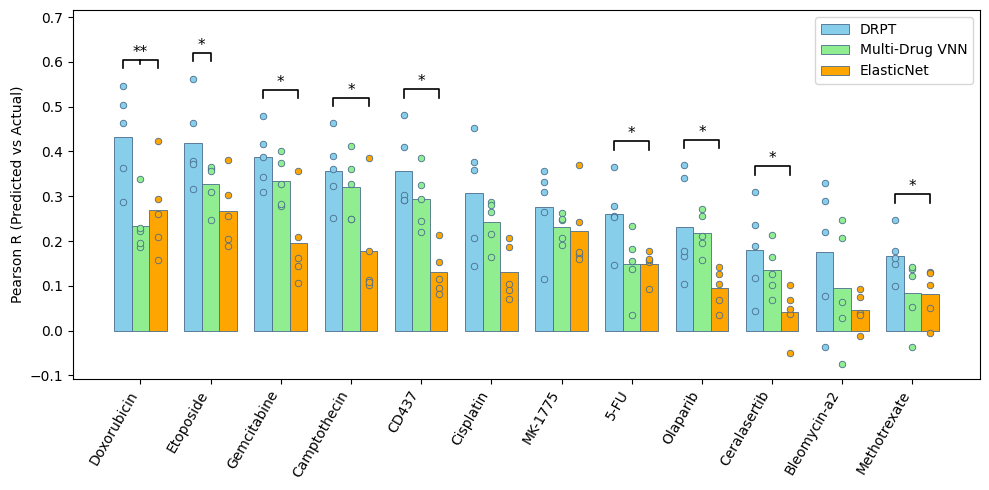

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

A = drpt_pearson
B = multi_pearson
C = results["elasticnet_pearson"]

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def paired_wilcoxon_greater(a, b):
    """One-sided paired Wilcoxon test: H1 = a > b. Drops NaN/inf pairs."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b)
    a = a[mask]
    b = b[mask]

    if len(a) < 2:
        return np.nan

    diffs = a - b
    if np.allclose(diffs, 0):
        return 1.0

    try:
        _, p = wilcoxon(a, b, alternative="greater", zero_method="wilcox")
        return float(p)
    except ValueError:
        return 1.0


def add_sig_bracket(ax, x1, x2, y, h, text, lw=1.2, mid_tick=False, tick_frac=0.45):
    """Draw a bracket from x1 to x2 at baseline y with height h; optional mid tick."""
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y],
            color="black", linewidth=lw, clip_on=False)

    if mid_tick:
        xm = (x1 + x2) / 2
        ax.plot([xm, xm], [y + h, y + h - tick_frac * h],
                color="black", linewidth=lw, clip_on=False)

    ax.text((x1 + x2) / 2, y + h, text,
            ha="center", va="bottom", fontsize=11, color="black", clip_on=False)


# ------------------------------------------------------------
# Convert lists of dicts -> DataFrames (rows=folds, cols=drugs)
# ------------------------------------------------------------
df_A = pd.DataFrame(A)
df_B = pd.DataFrame(B)
df_C = pd.DataFrame(C)

common = df_A.columns.intersection(df_B.columns).intersection(df_C.columns)
df_A = df_A[common]
df_B = df_B[common]
df_C = df_C[common]

sorted_indices = df_A.mean().sort_values(ascending=False).index
df_A = df_A[sorted_indices]
df_B = df_B[sorted_indices]
df_C = df_C[sorted_indices]

mean_values_A = df_A.mean().values
mean_values_B = df_B.mean().values
mean_values_C = df_C.mean().values

# ------------------------------------------------------------
# Plot positions
# ------------------------------------------------------------
x = np.arange(len(sorted_indices))
width = 0.25

xA = x - width   # DRPT
xB = x           # Multi-Drug VNN
xC = x + width   # ElasticNet

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(xA, mean_values_A, width, label='DRPT',
       alpha=1, color='skyblue', edgecolor="#4a6c8d", linewidth=0.6, zorder=1)
ax.bar(xB, mean_values_B, width, label='Multi-Drug VNN',
       alpha=1, color='lightgreen', edgecolor="#4a6c8d", linewidth=0.6, zorder=1)
ax.bar(xC, mean_values_C, width, label='ElasticNet',
       alpha=1, color='orange', edgecolor="#4a6c8d", linewidth=0.6, zorder=1)

for fold in range(df_A.shape[0]):
    ax.scatter(xA, df_A.iloc[fold].values, color='skyblue',
               edgecolor="#4a6c8d", linewidth=0.6, s=22, zorder=3)
for fold in range(df_B.shape[0]):
    ax.scatter(xB, df_B.iloc[fold].values, color='lightgreen',
               edgecolor="#4a6c8d", linewidth=0.6, s=22, zorder=3)
for fold in range(df_C.shape[0]):
    ax.scatter(xC, df_C.iloc[fold].values, color='orange',
               edgecolor="#4a6c8d", linewidth=0.6, s=22, zorder=3)

# ------------------------------------------------------------
# Significance bars (FIXED):
# If DRPT beats BOTH baselines: draw ONE bracket spanning ALL THREE bars (DRPT -> Elastic),
# with a mid tick and "**".
# ------------------------------------------------------------
all_points = np.concatenate([df_A.to_numpy().ravel(), df_B.to_numpy().ravel(), df_C.to_numpy().ravel()])
all_points = all_points[np.isfinite(all_points)]
yr = (np.nanmax(all_points) - np.nanmin(all_points)) if all_points.size else 1.0
pad = 0.06 * yr
h = 0.03 * yr

ax.set_ylim(bottom=ax.get_ylim()[0], top=max(ax.get_ylim()[1], np.nanmax(all_points) + 4 * pad))

for i, drug in enumerate(sorted_indices):
    a = df_A[drug].to_numpy(dtype=float)
    b = df_B[drug].to_numpy(dtype=float)
    c = df_C[drug].to_numpy(dtype=float)

    p_ab = paired_wilcoxon_greater(a, b)  # DRPT > Multi
    p_ac = paired_wilcoxon_greater(a, c)  # DRPT > Elastic

    sig_ab = (np.isfinite(p_ab) and p_ab < 0.05)
    sig_ac = (np.isfinite(p_ac) and p_ac < 0.05)

    if not (sig_ab or sig_ac):
        continue

    max_point_i = np.nanmax(
        np.concatenate([df_A[drug].to_numpy(float), df_B[drug].to_numpy(float), df_C[drug].to_numpy(float)])
    )
    y0 = max_point_i + pad

    if sig_ab and sig_ac:
        # Span ALL THREE model bars now (DRPT -> ElasticNet)
        add_sig_bracket(ax, xA[i], xC[i], y0, h, "**", mid_tick=True)
    elif sig_ab:
        add_sig_bracket(ax, xA[i], xB[i], y0, h, "*", mid_tick=False)
    elif sig_ac:
        add_sig_bracket(ax, xA[i], xC[i], y0, h, "*", mid_tick=False)

# Labels, title, legend
ax.set_ylabel('Pearson R (Predicted vs Actual)', fontsize=10)
ax.set_title('')
ax.set_xticks(x)
ax.set_xticklabels(sorted_indices, rotation=60, ha='right', fontsize=10)
ax.legend(fontsize=10)

fig.tight_layout()

out_svg = "drpt_vs_baselines_pearson.svg"   # change name as needed

plt.rcParams['svg.fonttype'] = 'none'

fig.savefig(
    out_svg,
    format="svg",
    bbox_inches="tight"
)

# (optional) also save a high-res PNG
fig.savefig(
    out_svg.replace(".svg", ".png"),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

### Spearman

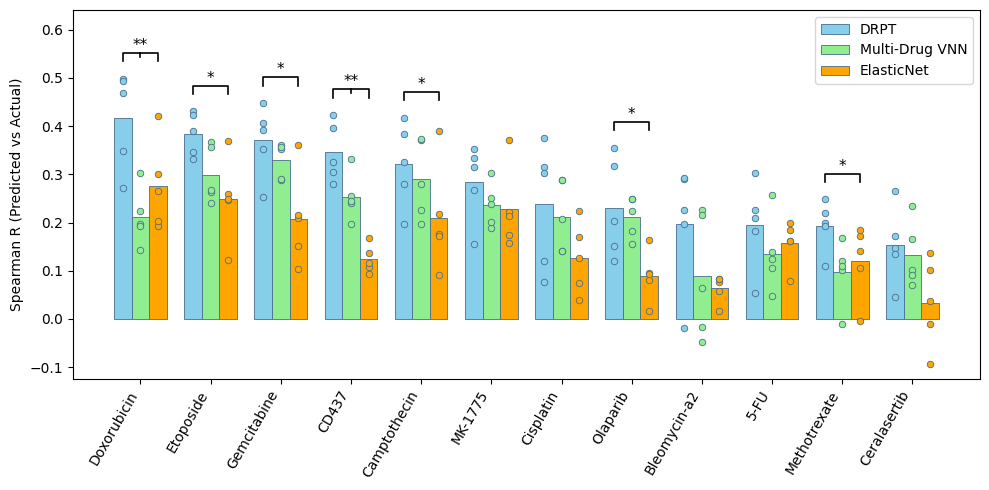

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

A = drpt_spearman
B = multi_spearman
C = results["elasticnet_spearman"]

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def paired_wilcoxon_greater(a, b):
    """One-sided paired Wilcoxon test: H1 = a > b. Drops NaN/inf pairs."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b)
    a = a[mask]
    b = b[mask]

    if len(a) < 2:
        return np.nan

    diffs = a - b
    if np.allclose(diffs, 0):
        return 1.0

    try:
        _, p = wilcoxon(a, b, alternative="greater", zero_method="wilcox")
        return float(p)
    except ValueError:
        return 1.0


def add_sig_bracket(ax, x1, x2, y, h, text, lw=1.2, mid_tick=False, tick_frac=0.45):
    """Draw a bracket from x1 to x2 at baseline y with height h; optional mid tick."""
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y],
            color="black", linewidth=lw, clip_on=False)

    if mid_tick:
        xm = (x1 + x2) / 2
        ax.plot([xm, xm], [y + h, y + h - tick_frac * h],
                color="black", linewidth=lw, clip_on=False)

    ax.text((x1 + x2) / 2, y + h, text,
            ha="center", va="bottom", fontsize=11, color="black", clip_on=False)


# ------------------------------------------------------------
# Convert lists of dicts -> DataFrames (rows=folds, cols=drugs)
# ------------------------------------------------------------
df_A = pd.DataFrame(A)
df_B = pd.DataFrame(B)
df_C = pd.DataFrame(C)

# Keep only common drugs (avoids misalignment)
common = df_A.columns.intersection(df_B.columns).intersection(df_C.columns)
df_A = df_A[common]
df_B = df_B[common]
df_C = df_C[common]

# Sort by DRPT mean
sorted_indices = df_A.mean().sort_values(ascending=False).index
df_A = df_A[sorted_indices]
df_B = df_B[sorted_indices]
df_C = df_C[sorted_indices]

mean_values_A = df_A.mean().values
mean_values_B = df_B.mean().values
mean_values_C = df_C.mean().values

# ------------------------------------------------------------
# Plot positions
# ------------------------------------------------------------
x = np.arange(len(sorted_indices))
width = 0.25

xA = x - width   # DRPT
xB = x           # Multi-Drug VNN
xC = x + width   # ElasticNet

fig, ax = plt.subplots(figsize=(10, 5))

# Mean bars (NO error bars)
ax.bar(xA, mean_values_A, width, label='DRPT',
       alpha=1, color='skyblue', edgecolor="#4a6c8d", linewidth=0.6, zorder=1)
ax.bar(xB, mean_values_B, width, label='Multi-Drug VNN',
       alpha=1, color='lightgreen', edgecolor="#4a6c8d", linewidth=0.6, zorder=1)
ax.bar(xC, mean_values_C, width, label='ElasticNet',
       alpha=1, color='orange', edgecolor="#4a6c8d", linewidth=0.6, zorder=1)

# Fold-level points
for fold in range(df_A.shape[0]):
    ax.scatter(xA, df_A.iloc[fold].values, color='skyblue',
               edgecolor="#4a6c8d", linewidth=0.6, s=22, zorder=3)
for fold in range(df_B.shape[0]):
    ax.scatter(xB, df_B.iloc[fold].values, color='lightgreen',
               edgecolor="#4a6c8d", linewidth=0.6, s=22, zorder=3)
for fold in range(df_C.shape[0]):
    ax.scatter(xC, df_C.iloc[fold].values, color='orange',
               edgecolor="#4a6c8d", linewidth=0.6, s=22, zorder=3)

# ------------------------------------------------------------
# Significance bars (same logic as Pearson plot):
# - One-sided paired Wilcoxon: DRPT > baseline
# - If DRPT beats BOTH baselines: ONE bracket spanning ALL THREE bars (DRPT -> Elastic),
#   labeled "**" with a mid tick.
# - If DRPT beats exactly one baseline: ONE bracket DRPT->that baseline labeled "*".
# - Brackets placed above the highest fold-level point for that drug.
# ------------------------------------------------------------
all_points = np.concatenate([df_A.to_numpy().ravel(), df_B.to_numpy().ravel(), df_C.to_numpy().ravel()])
all_points = all_points[np.isfinite(all_points)]
yr = (np.nanmax(all_points) - np.nanmin(all_points)) if all_points.size else 1.0
pad = 0.06 * yr
h = 0.03 * yr

ax.set_ylim(bottom=ax.get_ylim()[0], top=max(ax.get_ylim()[1], np.nanmax(all_points) + 4 * pad))

for i, drug in enumerate(sorted_indices):
    a = df_A[drug].to_numpy(dtype=float)
    b = df_B[drug].to_numpy(dtype=float)
    c = df_C[drug].to_numpy(dtype=float)

    p_ab = paired_wilcoxon_greater(a, b)  # DRPT > Multi
    p_ac = paired_wilcoxon_greater(a, c)  # DRPT > Elastic

    sig_ab = (np.isfinite(p_ab) and p_ab < 0.05)
    sig_ac = (np.isfinite(p_ac) and p_ac < 0.05)

    if not (sig_ab or sig_ac):
        continue

    max_point_i = np.nanmax(
        np.concatenate([df_A[drug].to_numpy(float), df_B[drug].to_numpy(float), df_C[drug].to_numpy(float)])
    )
    y0 = max_point_i + pad

    if sig_ab and sig_ac:
        add_sig_bracket(ax, xA[i], xC[i], y0, h, "**", mid_tick=True)
    elif sig_ab:
        add_sig_bracket(ax, xA[i], xB[i], y0, h, "*", mid_tick=False)
    elif sig_ac:
        add_sig_bracket(ax, xA[i], xC[i], y0, h, "*", mid_tick=False)

# Labels, title, legend
ax.set_ylabel('Spearman R (Predicted vs Actual)', fontsize=10)
ax.set_title('')
ax.set_xticks(x)
ax.set_xticklabels(sorted_indices, rotation=60, ha='right', fontsize=10)
ax.legend(fontsize=10)

fig.tight_layout()

out_svg = "drpt_vs_baselines_spearman.svg"   # change name as needed

plt.rcParams['svg.fonttype'] = 'none'

fig.savefig(
    out_svg,
    format="svg",
    bbox_inches="tight"
)

# (optional) also save a high-res PNG
fig.savefig(
    out_svg.replace(".svg", ".png"),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

### Odds

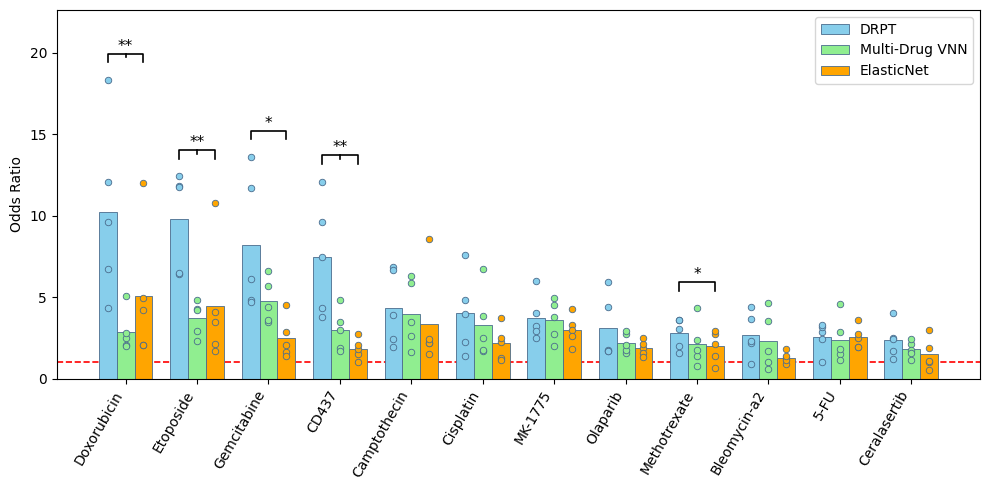

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

A = drpt_odds
B = multi_odds
C = results["elasticnet_odds"]

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def paired_wilcoxon_greater(a, b):
    """One-sided paired Wilcoxon test: H1 = a > b. Drops NaN/inf pairs."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b)
    a = a[mask]
    b = b[mask]

    if len(a) < 2:
        return np.nan

    diffs = a - b
    if np.allclose(diffs, 0):
        return 1.0

    try:
        _, p = wilcoxon(a, b, alternative="greater", zero_method="wilcox")
        return float(p)
    except ValueError:
        return 1.0


def add_sig_bracket(ax, x1, x2, y, h, text, lw=1.2, mid_tick=False, tick_frac=0.45):
    """Draw a bracket from x1 to x2 at baseline y with height h; optional mid tick."""
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y],
            color="black", linewidth=lw, clip_on=False)

    if mid_tick:
        xm = (x1 + x2) / 2
        ax.plot([xm, xm], [y + h, y + h - tick_frac * h],
                color="black", linewidth=lw, clip_on=False)

    ax.text((x1 + x2) / 2, y + h, text,
            ha="center", va="bottom", fontsize=11, color="black", clip_on=False)


# ------------------------------------------------------------
# Convert lists of dicts -> DataFrames (rows=folds, cols=drugs)
# ------------------------------------------------------------
df_A = pd.DataFrame(A)
df_B = pd.DataFrame(B)
df_C = pd.DataFrame(C)

# Keep only common drugs
common = df_A.columns.intersection(df_B.columns).intersection(df_C.columns)
df_A = df_A[common]
df_B = df_B[common]
df_C = df_C[common]

# Sort by DRPT mean odds ratio
sorted_indices = df_A.mean().sort_values(ascending=False).index
df_A = df_A[sorted_indices]
df_B = df_B[sorted_indices]
df_C = df_C[sorted_indices]

mean_values_A = df_A.mean().values
mean_values_B = df_B.mean().values
mean_values_C = df_C.mean().values

# ------------------------------------------------------------
# Plot positions
# ------------------------------------------------------------
x = np.arange(len(sorted_indices))
width = 0.25

xA = x - width   # DRPT
xB = x           # Multi-Drug VNN
xC = x + width   # ElasticNet

fig, ax = plt.subplots(figsize=(10, 5))

# Mean bars
ax.bar(xA, mean_values_A, width, label='DRPT',
       alpha=1, color='skyblue', edgecolor="#4a6c8d", linewidth=0.6, zorder=1)
ax.bar(xB, mean_values_B, width, label='Multi-Drug VNN',
       alpha=1, color='lightgreen', edgecolor="#4a6c8d", linewidth=0.6, zorder=1)
ax.bar(xC, mean_values_C, width, label='ElasticNet',
       alpha=1, color='orange', edgecolor="#4a6c8d", linewidth=0.6, zorder=1)

# Fold-level points
for fold in range(df_A.shape[0]):
    ax.scatter(xA, df_A.iloc[fold].values, color='skyblue',
               edgecolor="#4a6c8d", linewidth=0.6, s=22, zorder=3)
for fold in range(df_B.shape[0]):
    ax.scatter(xB, df_B.iloc[fold].values, color='lightgreen',
               edgecolor="#4a6c8d", linewidth=0.6, s=22, zorder=3)
for fold in range(df_C.shape[0]):
    ax.scatter(xC, df_C.iloc[fold].values, color='orange',
               edgecolor="#4a6c8d", linewidth=0.6, s=22, zorder=3)

# ------------------------------------------------------------
# Significance bars (same logic as Pearson/Spearman plots)
# ------------------------------------------------------------
all_points = np.concatenate([df_A.to_numpy().ravel(), df_B.to_numpy().ravel(), df_C.to_numpy().ravel()])
all_points = all_points[np.isfinite(all_points)]
yr = (np.nanmax(all_points) - np.nanmin(all_points)) if all_points.size else 1.0
pad = 0.06 * yr
h = 0.03 * yr

ax.set_ylim(bottom=ax.get_ylim()[0], top=max(ax.get_ylim()[1], np.nanmax(all_points) + 4 * pad))

for i, drug in enumerate(sorted_indices):
    a = df_A[drug].to_numpy(dtype=float)
    b = df_B[drug].to_numpy(dtype=float)
    c = df_C[drug].to_numpy(dtype=float)

    p_ab = paired_wilcoxon_greater(a, b)  # DRPT > Multi
    p_ac = paired_wilcoxon_greater(a, c)  # DRPT > Elastic

    sig_ab = (np.isfinite(p_ab) and p_ab < 0.05)
    sig_ac = (np.isfinite(p_ac) and p_ac < 0.05)

    if not (sig_ab or sig_ac):
        continue

    max_point_i = np.nanmax(
        np.concatenate([df_A[drug].to_numpy(float), df_B[drug].to_numpy(float), df_C[drug].to_numpy(float)])
    )
    y0 = max_point_i + pad

    if sig_ab and sig_ac:
        add_sig_bracket(ax, xA[i], xC[i], y0, h, "**", mid_tick=True)
    elif sig_ab:
        add_sig_bracket(ax, xA[i], xB[i], y0, h, "*", mid_tick=False)
    elif sig_ac:
        add_sig_bracket(ax, xA[i], xC[i], y0, h, "*", mid_tick=False)

# Labels, title, legend
ax.set_ylabel('Odds Ratio', fontsize=10)
ax.set_title('')
ax.set_xticks(x)
ax.set_xticklabels(sorted_indices, rotation=60, ha='right', fontsize=10)
ax.legend(fontsize=10)

# Optional: reference line at OR=1 (comment out if you don't want it)
ax.axhline(1.0, linestyle='--', linewidth=1.2, color='red', zorder=0)

fig.tight_layout()

out_svg = "drpt_vs_baselines_odds.svg"   # change name as needed

plt.rcParams['svg.fonttype'] = 'none'

fig.savefig(
    out_svg,
    format="svg",
    bbox_inches="tight"
)

# (optional) also save a high-res PNG
fig.savefig(
    out_svg.replace(".svg", ".png"),
    dpi=600,
    bbox_inches="tight"
)

plt.show()